# Brent Oil Prices — Exploratory Analysis and Change Point Prep

This notebook loads the Brent price series, runs diagnostics (trend, stationarity, volatility), and prepares the dataset for change point analysis. It also loads the compiled events dataset for mapping detected breaks to real-world events.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [3]:
# Load Brent prices (ensure the CSV exists at data/BrentOilPrices.csv)
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=[0], dayfirst=True, names=['Date','Price'], header=0)
df = df.rename(columns={'Date':'date','Price':'price'})
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.set_index('date').sort_index()
df = df.dropna(subset=['price'])
print('Loaded rows:', len(df))
df.head()

Loaded rows: 9011


,price
date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


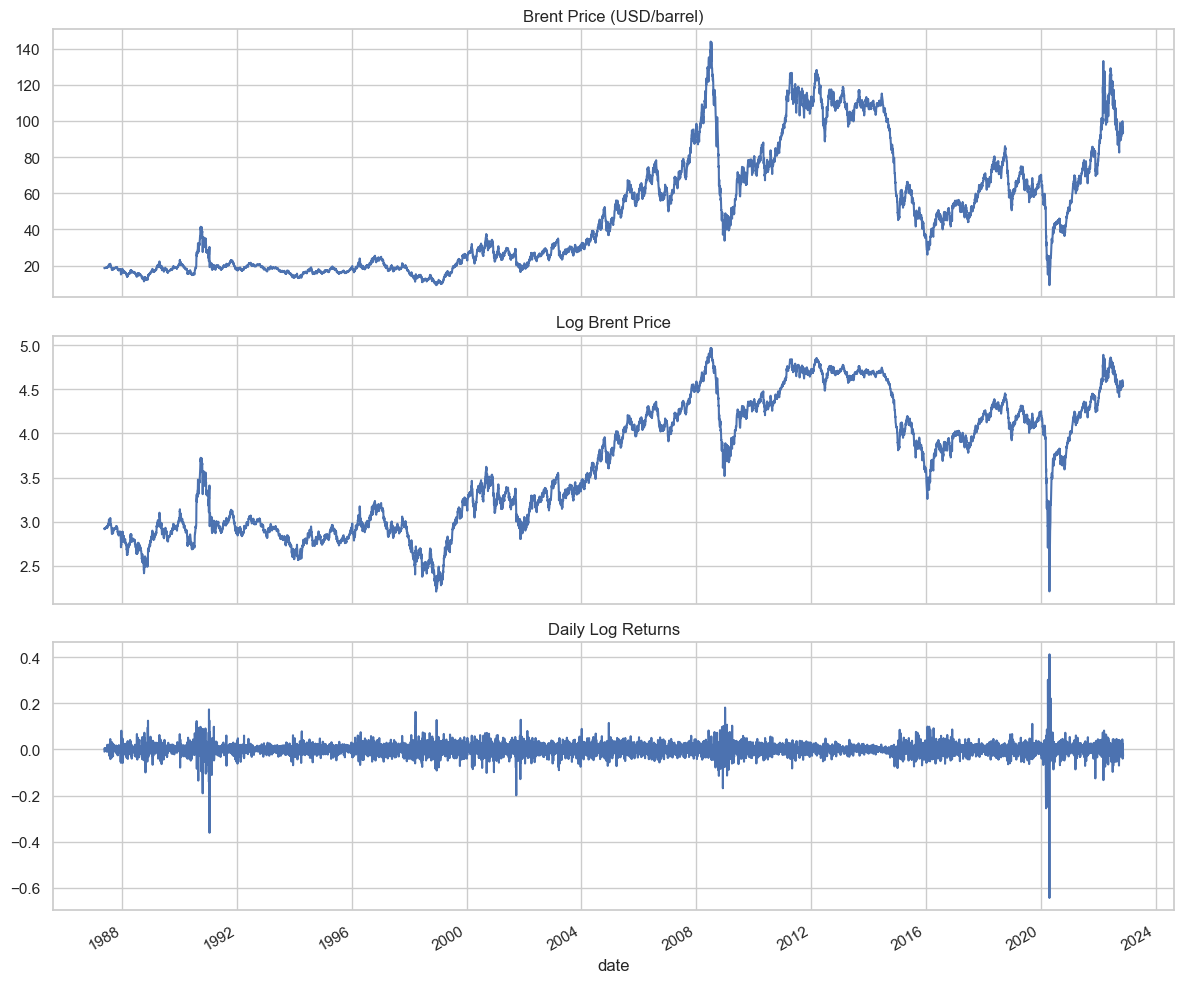

In [4]:
# Basic plots: price, log price, and returns
df['log_price'] = np.log(df['price'])
df['returns'] = df['log_price'].diff()
fig, axes = plt.subplots(3,1,figsize=(12,10), sharex=True)
df['price'].plot(ax=axes[0], title='Brent Price (USD/barrel)')
df['log_price'].plot(ax=axes[1], title='Log Brent Price')
df['returns'].plot(ax=axes[2], title='Daily Log Returns')
plt.tight_layout()
plt.show()

In [5]:
# Stationarity test (ADF) on levels and returns
def adf_test(series, name='series'):
    series = series.dropna()
    result = adfuller(series)
    print(f'ADF for {name}: stat={result[0]:.4f}, p-value={result[1]:.4f}')

adf_test(df['price'], 'price')
adf_test(df['log_price'], 'log_price')
adf_test(df['returns'], 'returns')

ADF for price: stat=-1.9939, p-value=0.2893
ADF for log_price: stat=-1.8089, p-value=0.3761
ADF for returns: stat=-16.4271, p-value=0.0000


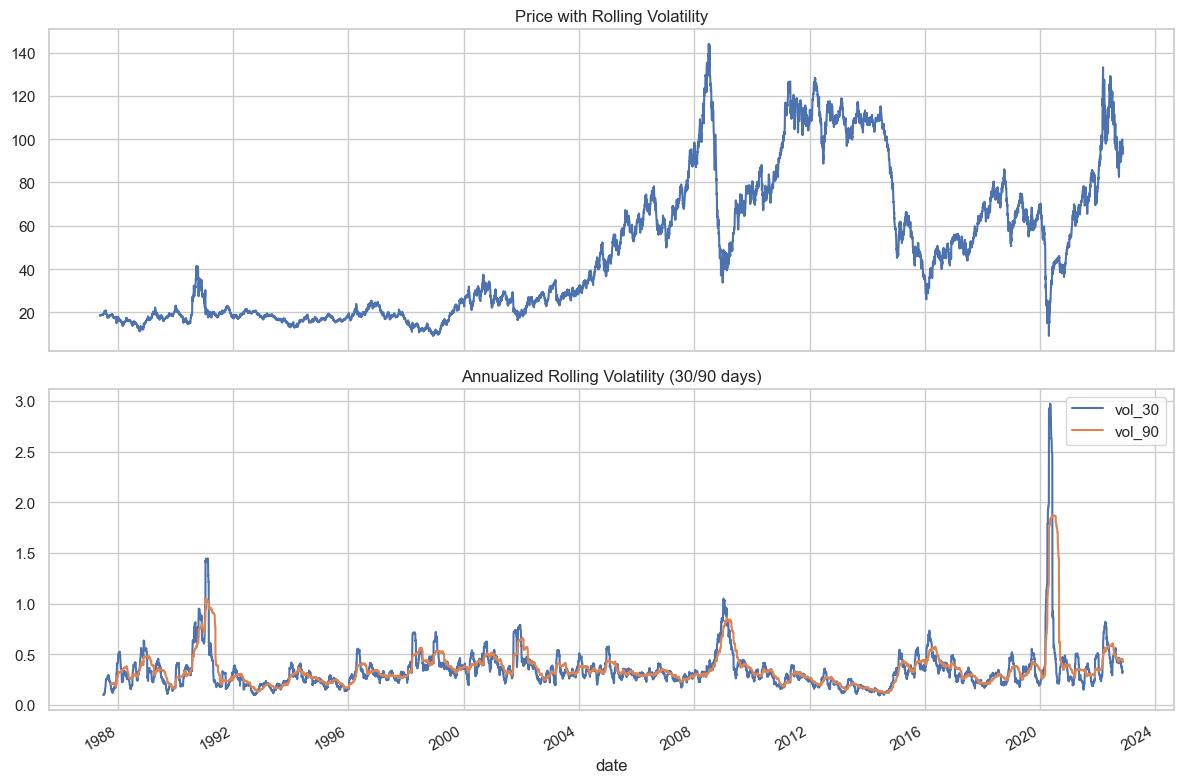

In [6]:
# Rolling volatility and trend
df['vol_30'] = df['returns'].rolling(30).std() * np.sqrt(252)
df['vol_90'] = df['returns'].rolling(90).std() * np.sqrt(252)
fig, ax = plt.subplots(2,1,figsize=(12,8), sharex=True)
df['price'].plot(ax=ax[0], title='Price with Rolling Volatility')
df[['vol_30','vol_90']].plot(ax=ax[1])
ax[1].set_title('Annualized Rolling Volatility (30/90 days)')
plt.tight_layout()
plt.show()

## Change point models — context and expectations
Change point models identify times at which the statistical properties of a time series (mean, variance, trend) change. Common methods include binary segmentation, PELT, and dynamic programming approaches. Expected outputs: a list of detected break dates, estimated parameters for segments (e.g., mean and variance), and diagnostic scores. Limitations: sensitivity to pre-processing, choice of cost function, and potential for multiple nearby detections requiring consolidation.

In [8]:
# Load compiled events to inspect mapping to breakpoints
events = pd.read_csv('../data/processed/events.csv', parse_dates=['date'])
events.head(20)

,date,event,category,description,source
0,2014-06-01,2014 OPEC Decision / Oil Price Collapse,Market/OPEC,Shift in OPEC policy and supply glut leading t...,https://www.bbc.com/news/business-30252440
1,2014-11-27,US Shale Boom Intensifies,Supply,US shale production growth contributes to over...,https://www.eia.gov/analysis/studies/usshale/
2,2016-01-01,2016 Global Demand Slowdown,Macro,Global economic slowdown concerns and oversupp...,https://www.imf.org/en/Publications
3,2018-05-08,US Withdrawal from Iran Nuclear Deal / Sanctions,Geo-Political,Re-imposition of US sanctions on Iran impacts ...,https://www.reuters.com/article/us-iran-nuclea...
4,2019-07-01,US-China Trade Tensions,Macro,Escalating trade tensions reduce global demand...,https://www.cnbc.com/2019/07/2019-us-china-tra...
5,2020-02-20,COVID-19 Global Demand Shock,Health/Pandemic,Global lockdowns sharply cut oil demand and co...,https://www.iea.org/reports/global-energy-revi...
6,2020-03-08,Saudi-Russia Price War,Market,Failure to agree on cuts leads to oil price cr...,https://www.nytimes.com/2020/04/20/business/en...
7,2020-04-12,OPEC+ Production Cuts Announced,Market/OPEC,Coordinated cuts to stabilize markets followin...,https://www.opec.org/opec_web/en/
8,2021-01-01,Slow Demand Recovery and Vaccine Rollout,Macro,Gradual recovery expectations as vaccines are ...,https://www.who.int/
9,2021-07-01,OPEC+ Gradual Production Increases,Market/OPEC,OPEC+ announces paced output increases influen...,https://www.opec.org/opec_web/en/
